<a href="https://colab.research.google.com/github/Malaika-05/AI-Training/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1️⃣ Import Libraries
We first import libraries needed for data manipulation and visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

#2️⃣ Load Dataset
Load the Titanic dataset and inspect first rows.

In [ ]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#3️⃣ Understand Dataset Structure
Shape of Dataset

In [ ]:
df.shape

(891, 15)

Column Names

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


#4️⃣ Check Duplicate Records

Duplicates can bias analysis.

In [ ]:
df.duplicated().sum()
# Remove duplicates if present:
df = df.drop_duplicates()

#5️⃣ Identify Feature Types

In [ ]:
# numerical
numerical_features = df.select_dtypes(include=['int64','float64']).columns
numerical_features

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [ ]:
# categorical
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['sex', 'embarked', 'who', 'embark_town', 'alive'], dtype='object')

#6️⃣ Summary Statistics

In [ ]:
# Numerical Summary
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,784.000000,784.000000,678.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,29.869351,0.522959,0.415816,34.711740
std,0.492507,0.855056,14.759076,0.986231,0.836922,52.160151
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.250000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.109350
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Categorical Summary
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,784,782,784,782,784
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,491,568,451,568,461


#7️⃣ Missing Value Analysis

In [ ]:
df.isnull().sum()
# Missing value percentage
missing_percent = df.isnull().mean()*100
missing_percent.sort_values(ascending=False)

,0
deck,74.234694
age,13.520408
embarked,0.255102
embark_town,0.255102
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000


Visualization of missing value

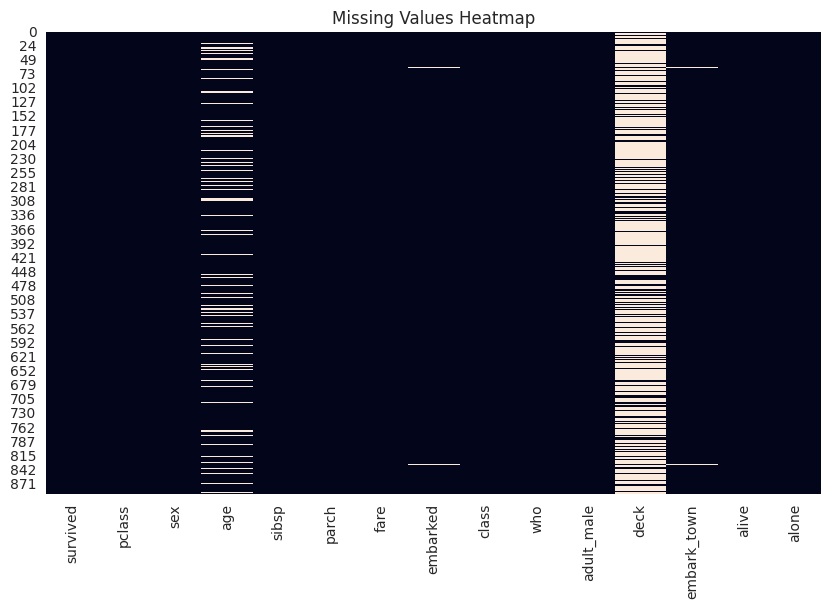

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

#8️⃣ Target Variable Analysis

Target variable = Survived

In [ ]:
df['survived'].value_counts()

,count
survived,
0,461
1,323


Survival Distribution

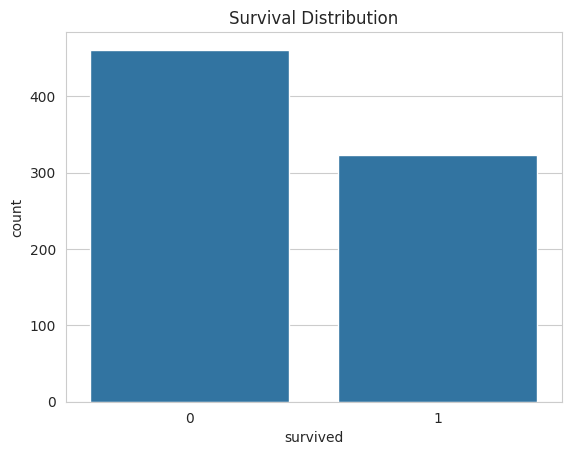

In [ ]:
sns.countplot(x='survived', data=df)

plt.title("Survival Distribution")
plt.show()

#9️⃣ Univariate Analysis (Numerical)

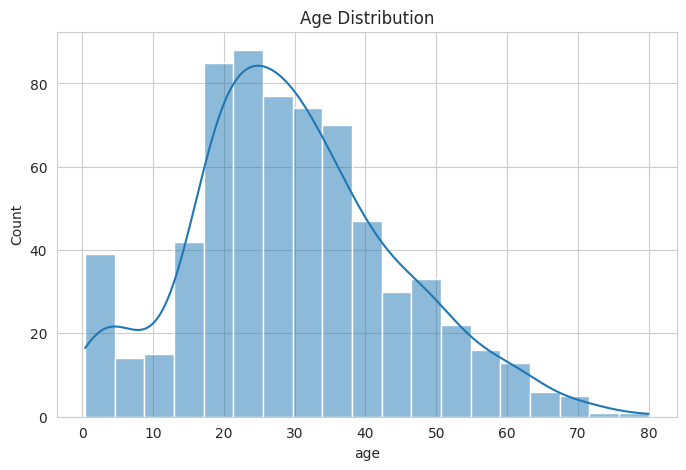

In [ ]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")
plt.show()

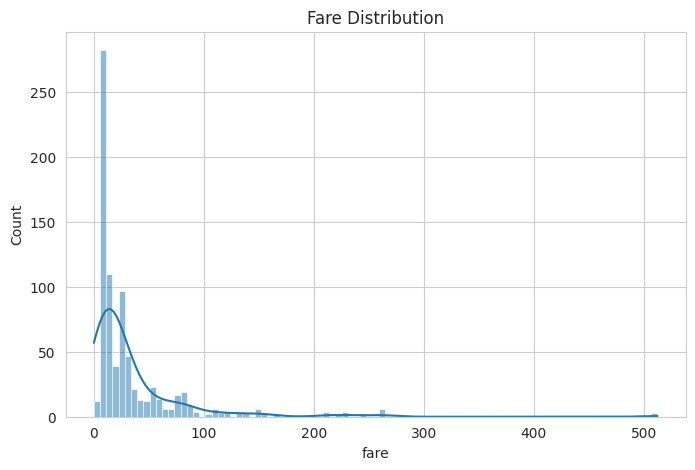

In [ ]:
# Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['fare'], kde=True)

plt.title("Fare Distribution")
plt.show()

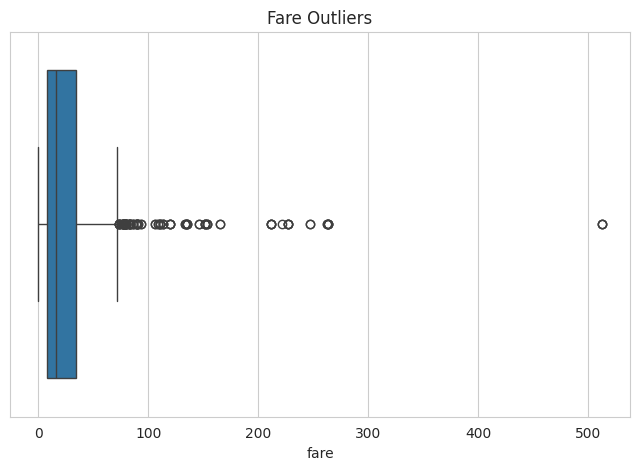

In [ ]:
# Boxplot for Outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare'])

plt.title("Fare Outliers")
plt.show()

#🔟 Univariate Analysis (Categorical)
Gender Distribution

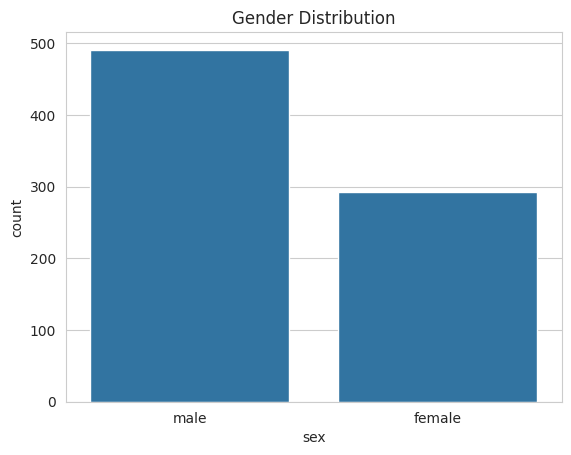

In [ ]:
sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")
plt.show()

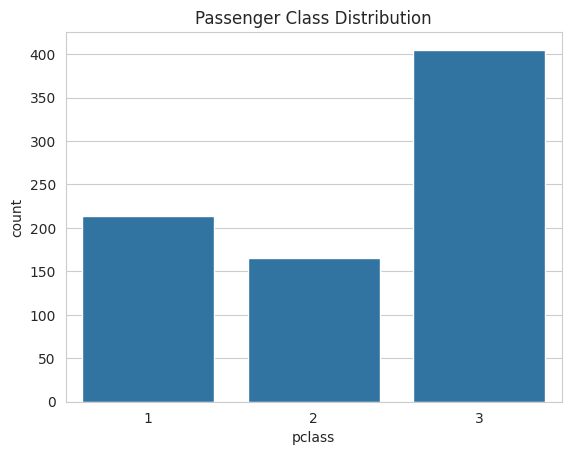

In [ ]:
# Passenger Class Distribution
sns.countplot(x='pclass', data=df)

plt.title("Passenger Class Distribution")
plt.show()

#1️⃣1️⃣ Bivariate Analysis

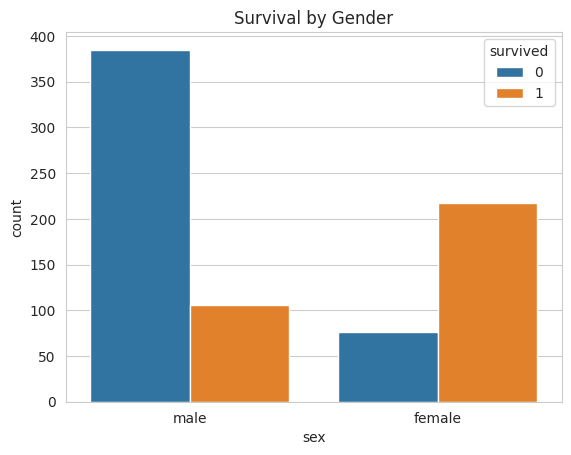

In [ ]:
# Gender vs survival
sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survival by Gender")
plt.show()

#1️⃣2️⃣ Correlation Analysis

            survived    pclass       age     sibsp     parch      fare  \
survived    1.000000 -0.332658 -0.086548 -0.036589  0.070307  0.246769   
pclass     -0.332658  1.000000 -0.369361  0.088014  0.040296 -0.549216   
age        -0.086548 -0.369361  1.000000 -0.315116 -0.195036  0.092707   
sibsp      -0.036589  0.088014 -0.315116  1.000000  0.381433  0.135147   
parch       0.070307  0.040296 -0.195036  0.381433  1.000000  0.191942   
fare        0.246769 -0.549216  0.092707  0.135147  0.191942  1.000000   
adult_male -0.528502  0.066816  0.296095 -0.274521 -0.347186 -0.165209   
alone      -0.176595  0.109545  0.210047 -0.609502 -0.571087 -0.246619   

            adult_male     alone  
survived     -0.528502 -0.176595  
pclass        0.066816  0.109545  
age           0.296095  0.210047  
sibsp        -0.274521 -0.609502  
parch        -0.347186 -0.571087  
fare         -0.165209 -0.246619  
adult_male    1.000000  0.387850  
alone         0.387850  1.000000  


<Axes: >

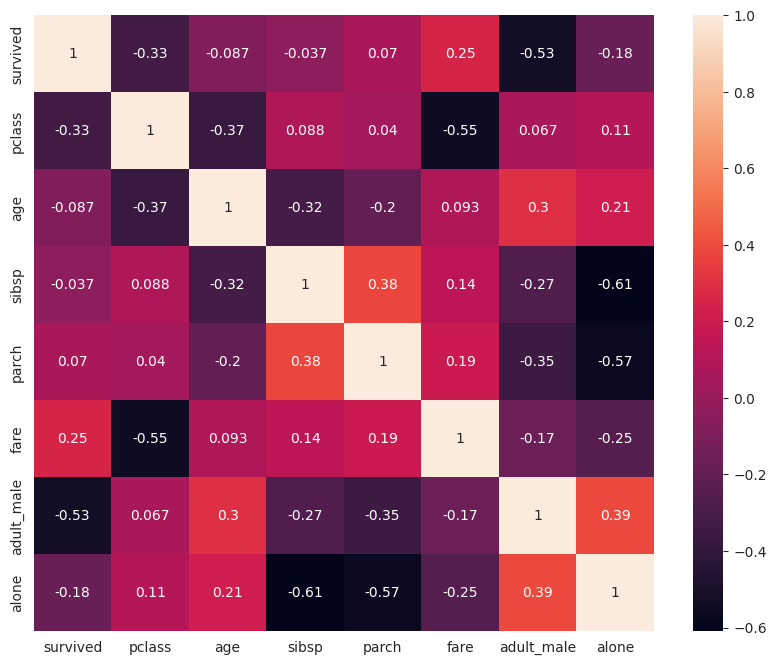

In [ ]:
# Correlation Matrix
corr = df.corr(numeric_only=True)
print(corr)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)

#1️⃣3️⃣ Outlier Detection

Detect extreme values

In [ ]:
# Using IQR method.

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)]

outliers.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True


#1️⃣4️⃣ Feature Engineering

In [ ]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

/tmp/ipykernel_169/1057222248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FamilySize'] = df['sibsp'] + df['parch'] + 1


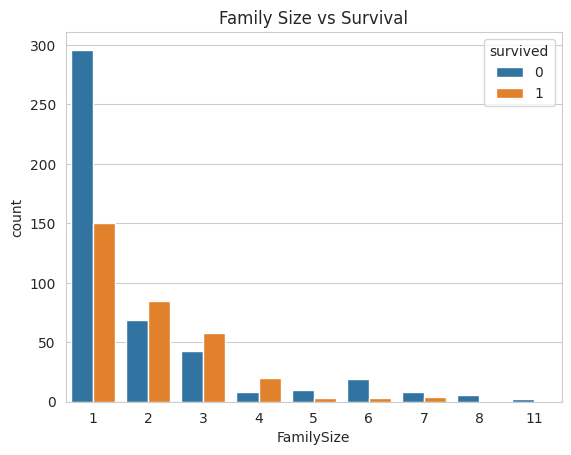

In [ ]:
# Visualization
sns.countplot(x='FamilySize', hue='survived', data=df)

plt.title("Family Size vs Survival")
plt.show()

# 1️⃣5️⃣ Handle Missing Values

In [ ]:
# Fill Age with Median
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipykernel_169/2749104353.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_169/2749104353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'].fillna(df['age'].median(), inplace=True)


In [ ]:
# Fill Embarked
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
# Drop Cabin (corrected to 'deck')
df.drop(columns=['deck'], inplace=True)

# Reason: too many missing values.

/tmp/ipykernel_169/2530007079.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
/tmp/ipykernel_169/2530007079.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
/tmp/ipykernel_169/2530007079.py:4: SettingWithCopyWarnin

#1️⃣6️⃣ Encode Categorical Variable

In [ ]:
df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)

#1️⃣7️⃣ Save Clean Dataset

In [ ]:
df.to_csv("titanic_cleaned.csv", index=False)

# Final EDA pipeline summary

1 Import libraries

2 Load dataset

3 Understand structure

4 Remove duplicates

5 Identify feature types

6 Summary statistics

7 Missing value analysis

8 Target analysis

9 Univariate analysis

10 Bivariate analysis

11 Correlation analysis

12 Outlier detection

13 Feature engineering

14 Handle missing values

15 Encoding

16 Save cleaned dataset